# ✂️ YOLO11x-seg — Instance Segmentation (누끼 따기)
- 바운딩박스 대신 **객체 테두리 마스크** 로 탐지
- 반투명 색상 오버레이 + 배경 제거(PNG) 동시 저장

같은 폴더에 `Box.jpg` 를 넣고 실행하세요.

In [1]:
!pip install "ultralytics>=8.3.0" opencv-python-headless matplotlib numpy -q

In [2]:
import sys
print(f"Python 버전: {sys.version}")

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import Counter
from ultralytics import YOLO
from koreanize_matplotlib import koreanize
koreanize()

INPUT_IMAGE = "box4.png"

if not Path(INPUT_IMAGE).exists():
    raise FileNotFoundError(f"'{INPUT_IMAGE}' 파일을 같은 폴더에 넣어주세요!")

img_bgr = cv2.imread(INPUT_IMAGE)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]
print(f"✅ 이미지 로드 완료: {w} x {h}")

Python 버전: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
✅ 이미지 로드 완료: 7337 x 6250


In [3]:
# YOLO11x-seg 로드 (최대 크기 segmentation 모델)
model = YOLO("yolo11x-seg.pt")
print(f"✅ YOLO11x-seg 로드 완료 | 클래스 수: {len(model.names)}개")

✅ YOLO11x-seg 로드 완료 | 클래스 수: 80개


In [4]:
# Segmentation 추론
results = model(
    INPUT_IMAGE,
    conf=0.15,
    iou=0.40,
    imgsz=1280,
    augment=True,
    retina_masks=True,   # 원본 해상도 마스크
    verbose=False,
)
result = results[0]

print(f"\n📦 탐지된 객체 수: {len(result.boxes)}개")
print("-" * 55)

detected = []
for i, box in enumerate(result.boxes):
    cls_id = int(box.cls[0].item())
    label  = model.names[cls_id]
    conf   = float(box.conf[0].item())
    x1, y1, x2, y2 = [int(v.item()) for v in box.xyxy[0]]
    detected.append({"label": label, "confidence": conf, "bbox": (x1, y1, x2, y2), "idx": i})
    print(f"  [{i+1:2d}] 🏷️  {label:25s} | {conf:.2%}")

WARNING Model does not support 'augment=True', reverting to single-scale prediction.

📦 탐지된 객체 수: 12개
-------------------------------------------------------
  [ 1] 🏷️  laptop                    | 94.26%
  [ 2] 🏷️  cell phone                | 92.14%
  [ 3] 🏷️  mouse                     | 87.94%
  [ 4] 🏷️  book                      | 79.57%
  [ 5] 🏷️  handbag                   | 72.49%
  [ 6] 🏷️  knife                     | 68.21%
  [ 7] 🏷️  cell phone                | 43.14%
  [ 8] 🏷️  handbag                   | 24.80%
  [ 9] 🏷️  knife                     | 18.39%
  [10] 🏷️  cell phone                | 15.95%
  [11] 🏷️  backpack                  | 15.68%
  [12] 🏷️  bench                     | 15.02%


In [5]:
detected

[{'label': 'laptop',
  'confidence': 0.9426285624504089,
  'bbox': (1830, 3571, 3644, 4864),
  'idx': 0},
 {'label': 'cell phone',
  'confidence': 0.9214481711387634,
  'bbox': (1876, 3057, 2331, 3497),
  'idx': 1},
 {'label': 'mouse',
  'confidence': 0.8793895840644836,
  'bbox': (1341, 4266, 1695, 4846),
  'idx': 2},
 {'label': 'book',
  'confidence': 0.7956520318984985,
  'bbox': (3641, 3347, 4824, 4827),
  'idx': 3},
 {'label': 'handbag',
  'confidence': 0.7249452471733093,
  'bbox': (1665, 2342, 2783, 3025),
  'idx': 4},
 {'label': 'knife',
  'confidence': 0.6821174025535583,
  'bbox': (1575, 3037, 1658, 3706),
  'idx': 5},
 {'label': 'cell phone',
  'confidence': 0.43135353922843933,
  'bbox': (2763, 2688, 3514, 3092),
  'idx': 6},
 {'label': 'handbag',
  'confidence': 0.24798181653022766,
  'bbox': (4527, 1589, 6708, 3146),
  'idx': 7},
 {'label': 'knife',
  'confidence': 0.18392527103424072,
  'bbox': (2360, 3247, 3519, 3465),
  'idx': 8},
 {'label': 'cell phone',
  'confidence

## 🎨 시각화 1 — 반투명 마스크 오버레이 (누끼 느낌)

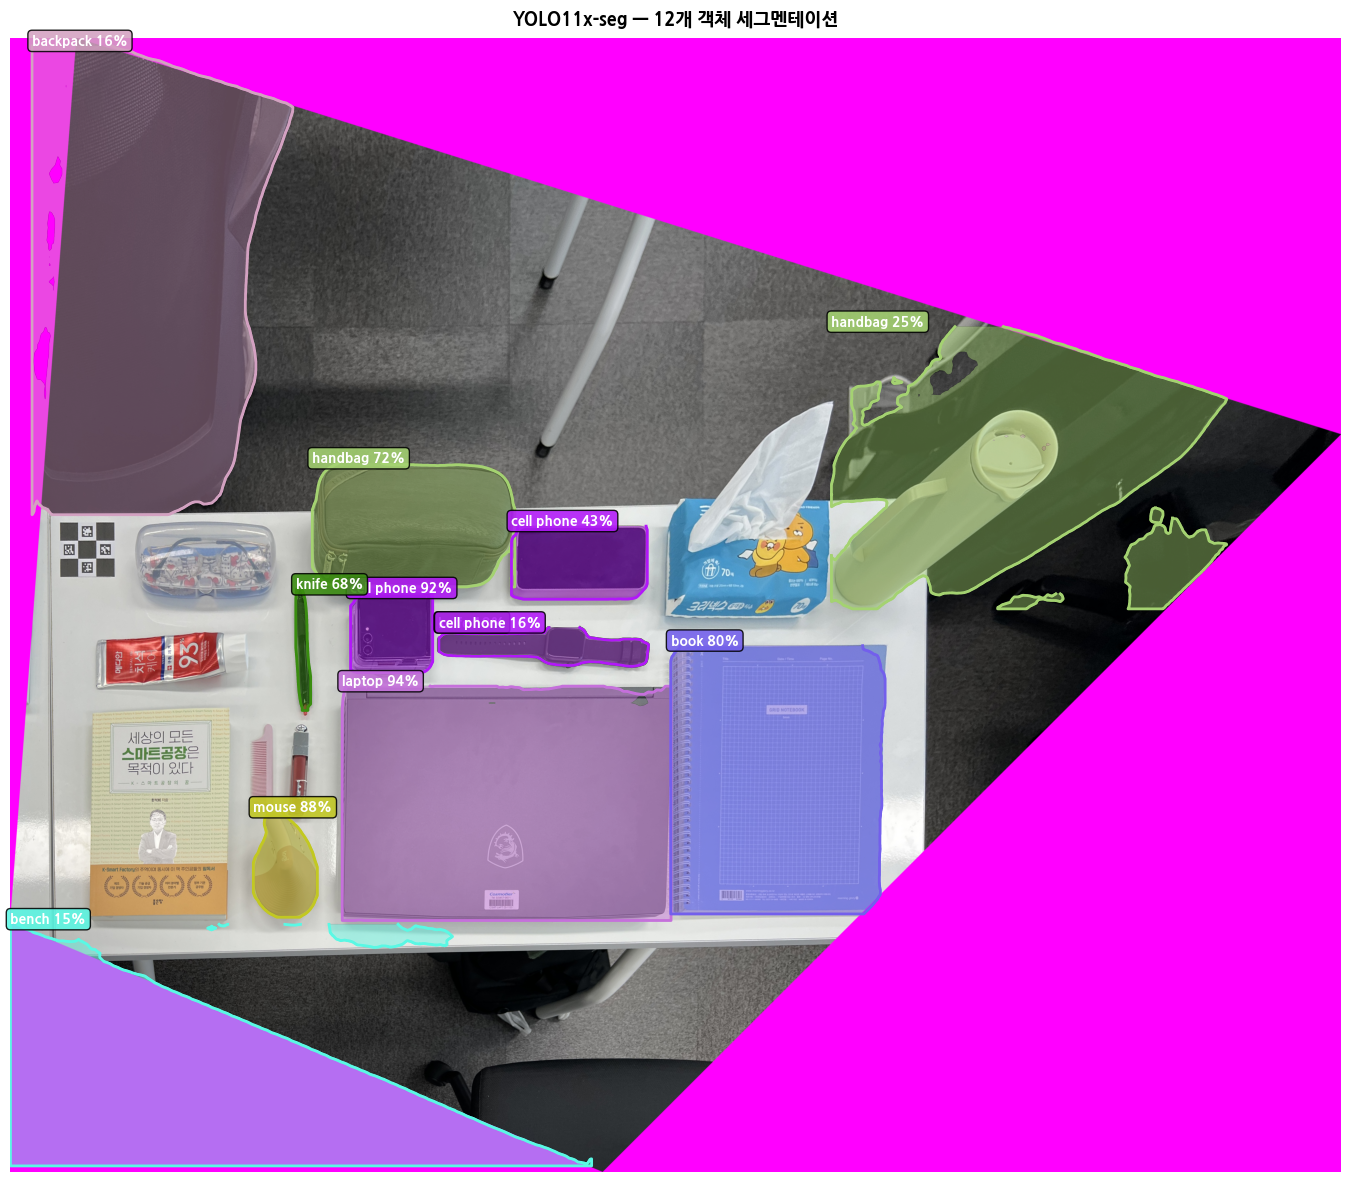

✅ 저장 완료: output_seg_overlay.png


In [6]:
fig_w = 14
fig_h = fig_w * h / w
fig, ax = plt.subplots(1, 1, figsize=(fig_w, fig_h))
ax.imshow(img_rgb)

rng = np.random.default_rng(42)
color_map = {}

# 마스크가 있는 경우
if result.masks is not None:
    masks_data = result.masks.data.cpu().numpy()  # (N, H, W)

    for obj in detected:
        idx   = obj["idx"]
        label = obj["label"]
        conf  = obj["confidence"]
        x1, y1, x2, y2 = obj["bbox"]

        # 클래스별 색상
        if label not in color_map:
            color_map[label] = rng.random(3)
        color = color_map[label]

        # 마스크 리사이즈 (원본 해상도에 맞게)
        mask = masks_data[idx]  # (H, W) float
        mask_resized = cv2.resize(mask, (w, h), interpolation=cv2.INTER_LINEAR)
        mask_bool = mask_resized > 0.5

        # 반투명 색상 오버레이
        overlay = np.zeros((h, w, 4), dtype=np.float32)
        overlay[mask_bool, :3] = color
        overlay[mask_bool, 3]  = 0.45  # 투명도
        ax.imshow(overlay)
        
        # 테두리 컨투어 그리기
        mask_uint8 = (mask_bool * 255).astype(np.uint8)
        contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            cnt_squeezed = cnt.squeeze()
            if cnt_squeezed.ndim == 2 and len(cnt_squeezed) > 2:
                ax.plot(
                    cnt_squeezed[:, 0], cnt_squeezed[:, 1],
                    color=color, linewidth=2.0
                )

        # 라벨 텍스트
        ax.text(
            x1, y1 - 8,
            f"{label} {conf:.0%}",
            fontsize=10, color="white", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.88)
        )
else:
    print("⚠️  마스크 없음 — 바운딩박스로 표시합니다.")
    for obj in detected:
        label = obj["label"]
        conf  = obj["confidence"]
        x1, y1, x2, y2 = obj["bbox"]
        if label not in color_map:
            color_map[label] = rng.random(3)
        color = color_map[label]
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2.5, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1-8, f"{label} {conf:.0%}", fontsize=10, color="white", fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.88))

ax.axis("off")
ax.set_title(f"YOLO11x-seg — {len(detected)}개 객체 세그멘테이션", fontsize=13, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("output_seg_overlay.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 저장 완료: output_seg_overlay.png")

## ✂️ 시각화 2 — 배경 제거 (객체만 PNG로 저장)

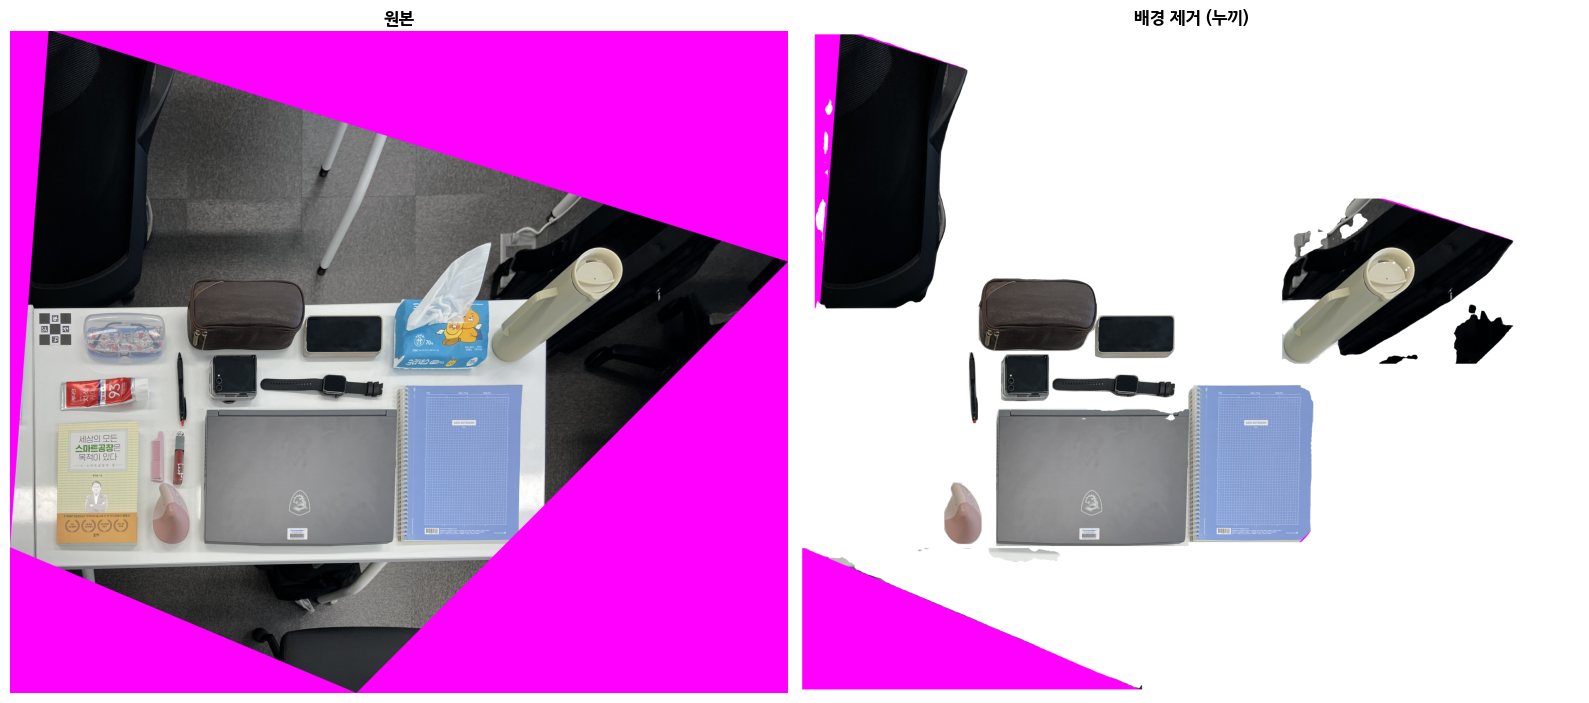

✅ 저장 완료: output_nobg.png (배경 투명 PNG)
✅ 저장 완료: output_compare.png (원본 vs 누끼 비교)


In [7]:
if result.masks is not None:
    # 전체 마스크 합산 (모든 객체 영역)
    masks_data = result.masks.data.cpu().numpy()
    combined_mask = np.zeros((h, w), dtype=np.float32)

    for i in range(len(masks_data)):
        m = cv2.resize(masks_data[i], (w, h), interpolation=cv2.INTER_LINEAR)
        combined_mask = np.maximum(combined_mask, m)

    combined_bool = combined_mask > 0.5

    # RGBA 이미지 생성 (배경 투명)
    img_rgba = np.dstack([img_rgb, np.ones((h, w), dtype=np.uint8) * 255])
    img_rgba[~combined_bool, 3] = 0  # 배경 알파=0 (투명)

    # PNG로 저장
    img_bgra = cv2.cvtColor(img_rgba, cv2.COLOR_RGBA2BGRA)
    cv2.imwrite("output_nobg.png", img_bgra)

    # 시각화
    fig2, axes = plt.subplots(1, 2, figsize=(16, fig_h * 16 / fig_w))
    axes[0].imshow(img_rgb)
    axes[0].set_title("원본", fontsize=12, fontweight="bold")
    axes[0].axis("off")

    axes[1].imshow(img_rgba)
    axes[1].set_title("배경 제거 (누끼)", fontsize=12, fontweight="bold")
    axes[1].axis("off")

    plt.tight_layout()
    plt.savefig("output_compare.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ 저장 완료: output_nobg.png (배경 투명 PNG)")
    print("✅ 저장 완료: output_compare.png (원본 vs 누끼 비교)")
else:
    print("⚠️  마스크 없음 — 배경 제거를 수행할 수 없습니다.")

In [8]:
# 개별 객체별 누끼 저장
if result.masks is not None:
    masks_data = result.masks.data.cpu().numpy()
    Path("objects").mkdir(exist_ok=True)

    for obj in detected:
        idx   = obj["idx"]
        label = obj["label"]
        x1, y1, x2, y2 = obj["bbox"]

        mask = cv2.resize(masks_data[idx], (w, h), interpolation=cv2.INTER_LINEAR)
        mask_bool = mask > 0.5

        # 해당 객체 영역만 크롭 + 배경 투명
        crop_rgba = np.dstack([img_rgb, np.ones((h, w), dtype=np.uint8) * 255])
        crop_rgba[~mask_bool, 3] = 0
        crop = crop_rgba[y1:y2, x1:x2]

        save_name = f"objects/{idx+1:02d}_{label}.png"
        cv2.imwrite(save_name, cv2.cvtColor(crop, cv2.COLOR_RGBA2BGRA))
        print(f"  저장: {save_name}")

    print(f"\n✅ 개별 객체 {len(detected)}개 저장 완료 → objects/ 폴더")

  저장: objects/01_laptop.png
  저장: objects/02_cell phone.png
  저장: objects/03_mouse.png
  저장: objects/04_book.png
  저장: objects/05_handbag.png
  저장: objects/06_knife.png
  저장: objects/07_cell phone.png
  저장: objects/08_handbag.png
  저장: objects/09_knife.png
  저장: objects/10_cell phone.png
  저장: objects/11_backpack.png
  저장: objects/12_bench.png

✅ 개별 객체 12개 저장 완료 → objects/ 폴더


In [9]:
# 클래스별 요약
print("\n📊 탐지 요약:")
print("-" * 40)
for label, cnt in Counter(o["label"] for o in detected).most_common():
    avg = np.mean([o["confidence"] for o in detected if o["label"] == label])
    print(f"  {label:25s}: {cnt}개  (평균 신뢰도: {avg:.1%})")


📊 탐지 요약:
----------------------------------------
  cell phone               : 3개  (평균 신뢰도: 50.4%)
  handbag                  : 2개  (평균 신뢰도: 48.6%)
  knife                    : 2개  (평균 신뢰도: 43.3%)
  laptop                   : 1개  (평균 신뢰도: 94.3%)
  mouse                    : 1개  (평균 신뢰도: 87.9%)
  book                     : 1개  (평균 신뢰도: 79.6%)
  backpack                 : 1개  (평균 신뢰도: 15.7%)
  bench                    : 1개  (평균 신뢰도: 15.0%)
